In [92]:
import pandas as pd 
import matplotlib.pyplot as plt
df_new = pd.read_csv('Global Superstore.csv')
df_new.head()
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer ID     51290 non-null  str    
 4   Customer Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  str    
 9   Order ID        51290 non-null  str    
 10  Order Priority  51290 non-null  str    
 11  Product ID      51290 non-null  str    
 12  Product Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

In [93]:
df_new.describe()

,Discount,ji_lu-shu,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [94]:
df_new.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [95]:
df_new.isnull().sum()

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
ji_lu-shu         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [96]:
top_profit = df_new.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(top_profit)

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


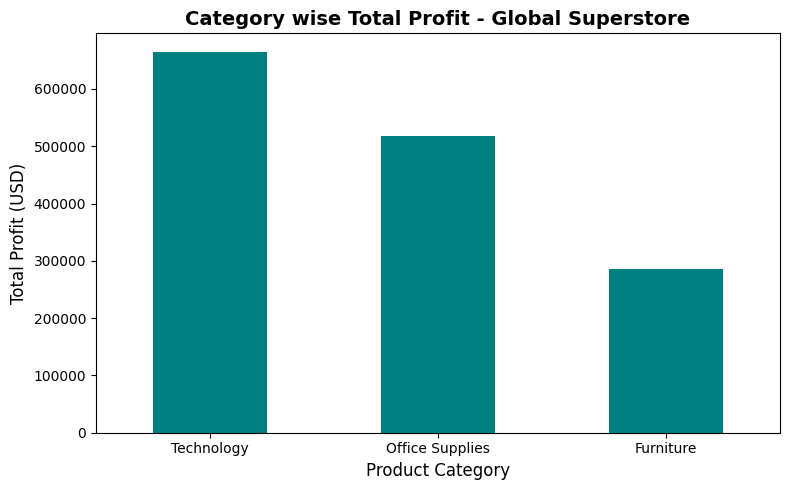

In [97]:
plt.figure(figsize=(8, 5))
top_profit.plot(kind='bar', color='teal')
plt.title('Category wise Total Profit - Global Superstore', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Profit (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [98]:
print(df_new.isnull().sum())

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
ji_lu-shu         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [99]:
df_new['Order Date'] = pd.to_datetime(df_new['Order Date'])
df_new['Month'] = df_new['Order Date'].dt.to_period('M')
monthly_sales = df_new.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
2026-05    12642905
Freq: M, Name: Sales, dtype: int64


c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


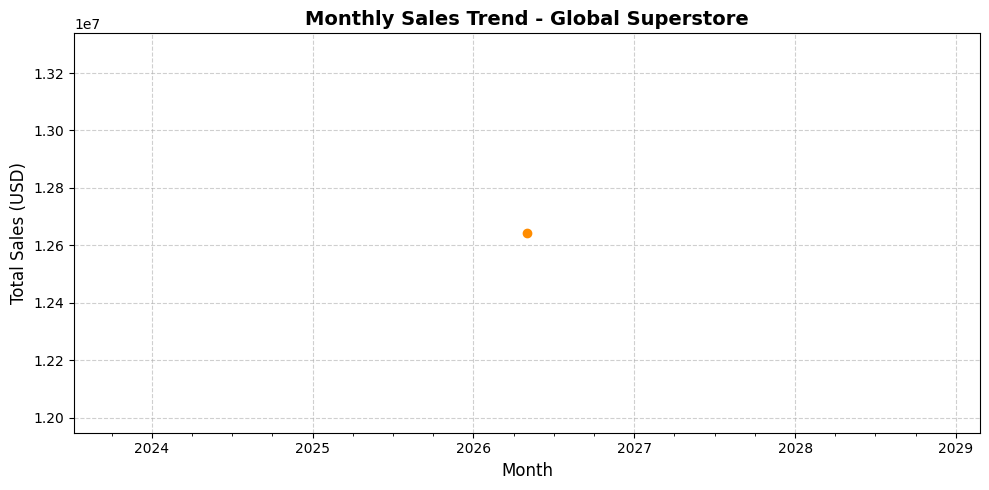

In [100]:
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o', color='darkorange', linewidth=2)
plt.title('Monthly Sales Trend - Global Superstore', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


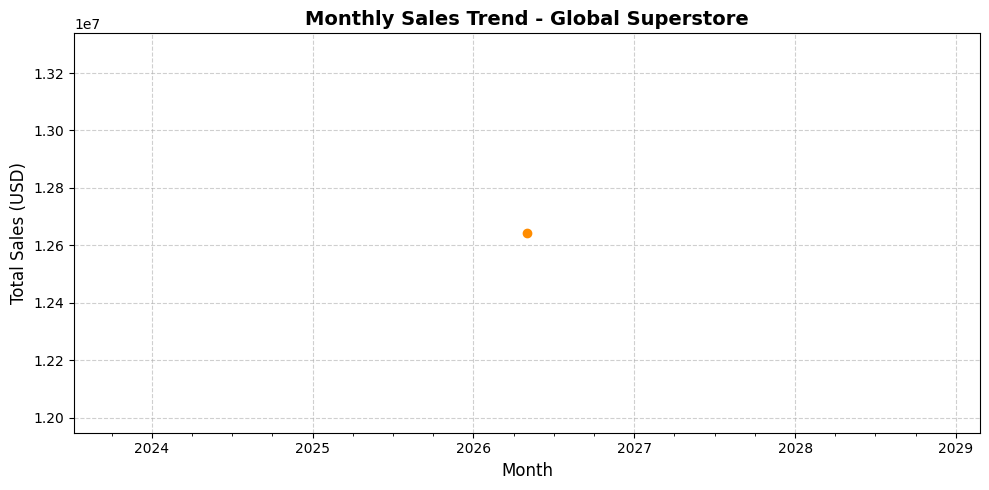

In [101]:
df_new['Order Date'] = pd.to_datetime(df_new['Order Date'])
df_new['Month_Year'] = df_new['Order Date'].dt.to_period('M')
monthly_sales = df_new.groupby('Month_Year')['Sales'].sum()
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line',marker='o', color='darkorange', linewidth=2)
plt.title('Monthly Sales Trend - Global Superstore', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.grid('True', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [102]:
country_profit = df_new.groupby('Country')['Profit'].sum().sort_values(ascending=False)
print('--- TOP 5 PROFITABLE COUNTRIES ---')
print(country_profit.head(5))
print('\n--- TOP LOSS-MAKING COUNTRIES ---')
print(country_profit.tail(5))

--- TOP 5 PROFITABLE COUNTRIES ---
Country
United States     286397.0217
China             150683.0850
India             129071.8350
United Kingdom    111900.1500
France            109029.0030
Name: Profit, dtype: float64

--- TOP LOSS-MAKING COUNTRIES ---
Country
Pakistan      -22446.6480
Honduras      -29482.3714
Netherlands   -41070.0750
Nigeria       -80750.7180
Turkey        -98447.2320
Name: Profit, dtype: float64


In [103]:
ship_analysis = df_new.groupby('Ship Mode')[['Profit', 'Shipping Cost']].mean()
print(ship_analysis)

                   Profit  Shipping Cost
Ship Mode                               
First Class     27.728804      41.052970
Same Day        28.201802      42.937325
Second Class    28.381368      30.469666
Standard Class  28.938945      19.971654


In [104]:
loss_df = df_new[df_new['Profit'] < 0]
print('Loss count by Category:')
print(loss_df['Category'].value_counts().head())
loss_df.to_csv('Loss_Making_Order', index=False)


Loss count by Category:
Category
Office Supplies    7003
Furniture          3117
Technology         2424
Name: count, dtype: int64


In [105]:
print('--- Missing Values in Dataset ---')
print(df_new.isnull().sum())
print('\n--- Data Types of Columns ---')
print(df_new.dtypes)

--- Missing Values in Dataset ---
Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
ji_lu-shu         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
Month             0
Month_Year        0
dtype: int64

--- Data Types of Columns ---
Category                     str
City                         str
Country                      str
Customer ID                  str
Customer Name                str
Discount                 float64
Market                       str
ji_lu-shu                  int64
Order Date        datetime64[us]
Order ID                     str
Order Priori

In [106]:
high_value_orders = df_new[(df_new['Sales'] > 500) & (df_new['Profit'] > 0)]
print('--- High-Value Profitable Orders Summary ---')
print(high_value_orders[['Order ID', 'Category', 'Sales', 'Profit',]].head())

--- High-Value Profitable Orders Summary ---
           Order ID         Category  Sales    Profit
196  CA-2011-106726  Office Supplies   1261  327.9458
200  CA-2012-116092  Office Supplies    541  157.0176
201  CA-2012-142601  Office Supplies    947    9.4717
221  CA-2013-114972  Office Supplies   1101  429.5772
226  CA-2013-158694  Office Supplies    721  187.3976


In [107]:
market_summary = df_new.groupby(['Market', 'Region'])['Profit'].sum().unstack().fillna(0)
print('--- Market & Region wise Profit Matrix ---')
print(market_summary)

--- Market & Region wise Profit Matrix ---
Region     Africa    Canada    Caribbean       Central  Central Asia  \
Market                                                                 
APAC        0.000      0.00      0.00000       0.00000    132480.187   
Africa  88871.631      0.00      0.00000       0.00000         0.000   
Canada      0.000  17817.39      0.00000       0.00000         0.000   
EMEA        0.000      0.00      0.00000       0.00000         0.000   
EU          0.000      0.00      0.00000  215534.06850         0.000   
LATAM       0.000      0.00  34571.32104   56163.55064         0.000   
US          0.000      0.00      0.00000   39706.36250         0.000   

Region       EMEA      East         North  North Asia     Oceania  \
Market                                                              
APAC        0.000      0.00       0.00000  165578.421  120089.112   
Africa      0.000      0.00       0.00000       0.000       0.000   
Canada      0.000      0.00     

In [108]:
discount_pref = df_new.groupby('Discount')['Profit'].mean().reset_index()
print('---- Discount VS Average Profit Analysis ----')
print(discount_pref)
discount_pref.to_csv('Discount_Profitability_Analysis.csv', index=False)
print("\n Final analysis report bhi 'Discount_Profitability_Analysis.csv' naam se save ho gyi hai!")

---- Discount VS Average Profit Analysis ----
    Discount       Profit
0      0.000    61.039514
1      0.002   125.762649
2      0.070   140.990022
3      0.100    63.683426
4      0.150    50.602409
5      0.170    38.317107
6      0.200    23.552594
7      0.202   -14.518847
8      0.250     4.043371
9      0.270    -4.317213
10     0.300   -57.899557
11     0.320   -88.560656
12     0.350  -116.144693
13     0.370   -78.462191
14     0.400   -45.246603
15     0.402  -109.908138
16     0.450   -41.610973
17     0.470   -42.982420
18     0.500   -97.140158
19     0.550  -315.067200
20     0.570  -526.129000
21     0.600   -81.732147
22     0.602  -213.279085
23     0.650  -365.997971
24     0.700  -104.339576
25     0.800  -122.203244
26     0.850 -1534.329000

 Final analysis report bhi 'Discount_Profitability_Analysis.csv' naam se save ho gyi hai!
